In [7]:
%matplotlib widget

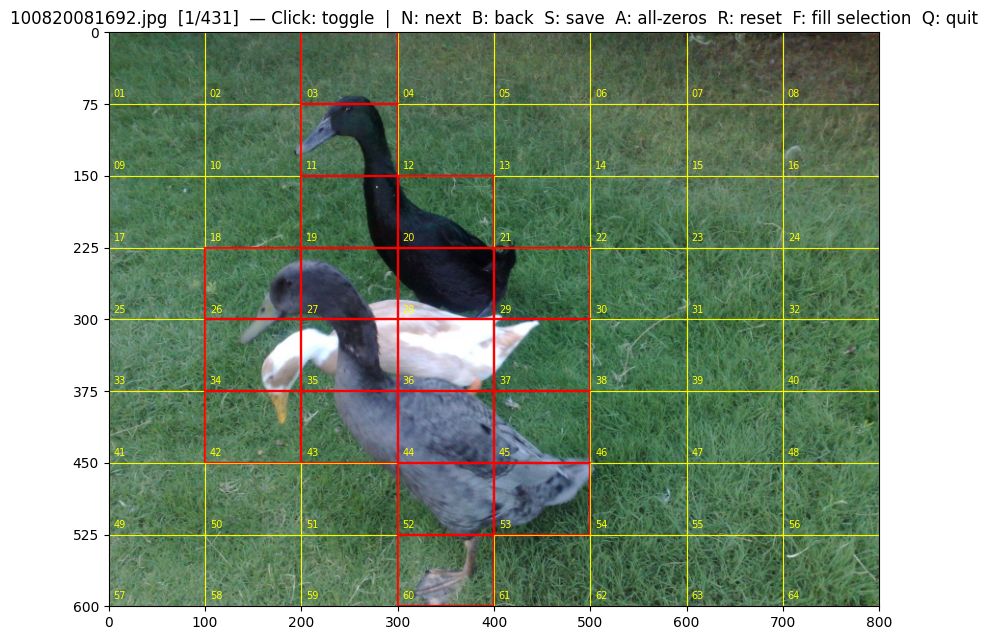

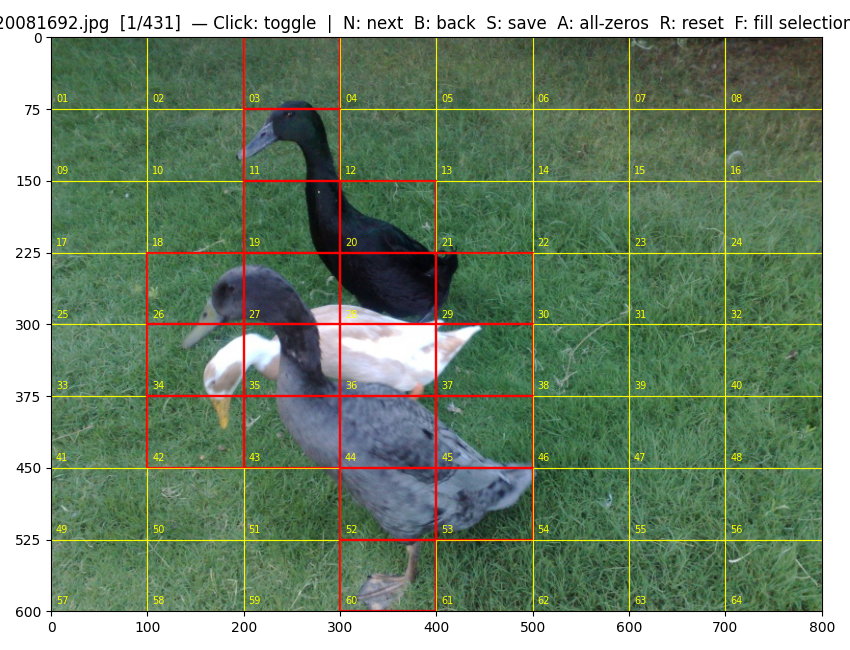

In [8]:
# --- Notebook-friendly Grid Annotator (VS Code + %matplotlib widget) ---

import os, sys, math, json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
from IPython.display import display  # <-- to display the live figure inline

# Disable Matplotlib's default "save figure" shortcut so 's' doesn't open a dialog
mpl.rcParams['keymap.save'] = []

# ------------------ CONFIG ------------------
PREPROCESSED_DIR = "/home/pratyush/Desktop/DS_Project/data/preprocessed"
LABELS_CSV      = "/home/pratyush/Desktop/DS_Project/data/label.csv"
OVERLAY_DIR     = "/home/pratyush/Desktop/DS_Project/outputs/overlays"  # optional saved overlays
os.makedirs(os.path.dirname(LABELS_CSV), exist_ok=True)
os.makedirs(OVERLAY_DIR, exist_ok=True)

TARGET_W, TARGET_H = 800, 600
GRID_W, GRID_H = 8, 8
CELL_W, CELL_H = TARGET_W // GRID_W, TARGET_H // GRID_H  # 100x75

# Numbering c01..c64 in row-major (top-left = c01)
COL_NAMES = ["image"] + [f"c{i:02d}" for i in range(1, GRID_W * GRID_H + 1)]

# ------------------ HELPERS ------------------
def list_images(folder):
    exts = (".jpg", ".jpeg", ".png", ".bmp")
    files = [f for f in os.listdir(folder) if f.lower().endswith(exts)]
    files.sort()
    return files

def cell_index_from_xy(x, y):
    """Return 0-based cell index in row-major order, or None if outside."""
    if x is None or y is None:
        return None
    if x < 0 or y < 0 or x >= TARGET_W or y >= TARGET_H:
        return None
    cx = min(int(x // CELL_W), GRID_W-1)   # 0..7
    cy = min(int(y // CELL_H), GRID_H-1)   # 0..7
    return cy * GRID_W + cx                # 0..63

def index_to_rc(idx):
    """0-based -> (row, col)"""
    r = idx // GRID_W
    c = idx % GRID_W
    return r, c

def rc_to_rect(r, c):
    """Return matplotlib Rectangle for cell (r,c)."""
    x = c * CELL_W
    y = r * CELL_H
    return patches.Rectangle((x, y), CELL_W, CELL_H, fill=False, linewidth=0.8)

def labels_to_array(row_dict):
    return np.array([row_dict[f"c{i:02d}"] for i in range(1, GRID_W*GRID_H+1)], dtype=int)

def array_to_row(img_name, arr):
    d = {"image": img_name}
    for i in range(1, GRID_W*GRID_H+1):
        d[f"c{i:02d}"] = int(arr[i-1])
    return d

# ------------------ LOAD / INIT LABELS ------------------
if os.path.exists(LABELS_CSV):
    df_labels = pd.read_csv(LABELS_CSV)
    # Ensure correct columns/order if the file already exists
    missing = [c for c in COL_NAMES if c not in df_labels.columns]
    for m in missing:
        df_labels[m] = 0
    df_labels = df_labels[COL_NAMES]
    # (1) Keep only rows that have at least one '1'
    if len(df_labels) > 0:
        label_cols = COL_NAMES[1:]
        df_labels = df_labels[df_labels[label_cols].sum(axis=1) > 0].reset_index(drop=True)
else:
    df_labels = pd.DataFrame(columns=COL_NAMES)

images = list_images(PREPROCESSED_DIR)
if not images:
    print(f"No images found in {PREPROCESSED_DIR}")
    raise SystemExit

# ------------------ ANNOTATOR CLASS ------------------
class GridAnnotator:
    def __init__(self, images, df):
        self.images = images
        self.df = df
        self.idx = 0  # current image index
        self.sel = set()  # optional selection mode (drag select)
        self.dragging = False
        self.start_rect = None

        self.fig, self.ax = plt.subplots(figsize=(8.5, 6.5))
        # NOTE: widget backend: no window title
        self.cid_click = self.fig.canvas.mpl_connect('button_press_event', self.on_click)
        self.cid_release = self.fig.canvas.mpl_connect('button_release_event', self.on_release)
        self.cid_motion = self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        self.cid_key = self.fig.canvas.mpl_connect('key_press_event', self.on_key)

        self.rects = []   # grid rectangles
        self.fill_over = None  # drag rectangle
        self.texts = []   # cell number texts

        self.load_image()
        plt.tight_layout()
        display(self.fig)   # <-- display inline widget (instead of plt.show())

    # ---------- label row helpers (store only labeled images) ----------
    def get_row(self, imgname):
        # If not in CSV yet, behave like all zeros (not persisted until you save with some 1s)
        if "image" in self.df.columns and (self.df["image"] == imgname).any():
            return self.df[self.df["image"] == imgname].iloc[0]
        return pd.Series(array_to_row(imgname, np.zeros(GRID_W*GRID_H, dtype=int)))

    def set_row(self, imgname, arr):
        # If any positive -> upsert; else remove row from CSV (keep file clean)
        has_pos = int(np.any(np.array(arr) == 1))
        if has_pos:
            if (self.df["image"] == imgname).any():
                self.df.loc[self.df["image"] == imgname, COL_NAMES[1:]] = arr
            else:
                self.df = pd.concat(
                    [self.df, pd.DataFrame([array_to_row(imgname, np.array(arr))])],
                    ignore_index=True
                )
        else:
            # remove if present (only-zero labels are not stored)
            self.df = self.df[self.df["image"] != imgname].reset_index(drop=True)

    # ---------- UI / drawing ----------
    def load_image(self):
        self.ax.clear()
        imgname = self.images[self.idx]
        path = os.path.join(PREPROCESSED_DIR, imgname)

        # load image (expect 800x600)
        img = plt.imread(path)
        self.ax.imshow(img, extent=[0, TARGET_W, TARGET_H, 0], aspect="auto")

        # draw grid
        self.rects = []
        for r in range(GRID_H):
            for c in range(GRID_W):
                rect = rc_to_rect(r, c)
                self.ax.add_patch(rect)
                self.rects.append(rect)

        # draw cell numbers
        self.texts = []
        for idx in range(GRID_W * GRID_H):
            r, c = index_to_rc(idx)
            x = c * CELL_W + 5
            y = (r + 1) * CELL_H - 5
            t = self.ax.text(x, y, f"{idx+1:02d}", fontsize=7, color="yellow", va="bottom", ha="left")
            self.texts.append(t)

        # load labels (defaults to zeros if not present)
        row = self.get_row(imgname).to_dict()
        self.arr = labels_to_array(row)

        # color positives
        self.refresh_colors()

        self.ax.set_xlim(0, TARGET_W)
        self.ax.set_ylim(TARGET_H, 0)
        self.ax.set_xticks(np.arange(0, TARGET_W+1, CELL_W))
        self.ax.set_yticks(np.arange(0, TARGET_H+1, CELL_H))
        self.ax.grid(False)
        self.ax.set_title(
            f"{imgname}  [{self.idx+1}/{len(self.images)}]  — "
            "Click: toggle  |  N: next  B: back  S: save  "
            "A: all-zeros  R: reset  F: fill selection  Q: quit"
        )

        self.fig.canvas.draw_idle()

    def refresh_colors(self):
        # stronger highlight for positives; yellowish grid for others
        for i, rect in enumerate(self.rects):
            if self.arr[i] == 1:
                rect.set_facecolor((1, 0, 0, 0.35))     # brighter translucent red
                rect.set_edgecolor((1, 0, 0, 0.9))      # red border
                rect.set_linewidth(1.6)
            else:
                rect.set_facecolor((0, 0, 0, 0.0))
                rect.set_edgecolor((1, 1, 0, 0.8))      # grid lines
                rect.set_linewidth(0.8)
        self.fig.canvas.draw_idle()

    def pulse_cell(self, cell_idx):
        # brief cyan outline to confirm the click
        rect = self.rects[cell_idx]
        old_ec = rect.get_edgecolor()
        old_lw = rect.get_linewidth()
        rect.set_edgecolor('cyan')
        rect.set_linewidth(2.5)
        self.fig.canvas.draw_idle()

        timer = self.fig.canvas.new_timer(interval=120)  # ms
        def _restore():
            rect.set_edgecolor(old_ec)
            rect.set_linewidth(old_lw)
            self.fig.canvas.draw_idle()
        timer.add_callback(_restore)
        timer.start()

    def toggle_cell(self, cell_idx):
        new_val = 1 - self.arr[cell_idx]
        self.arr[cell_idx] = new_val
        self.refresh_colors()
        # (4) Only pulse on turning ON to avoid flutter when turning OFF
        if new_val == 1:
            self.pulse_cell(cell_idx)

    # ---------- events ----------
    def on_click(self, event):
        if event.inaxes != self.ax:
            return
        if event.button == 1:  # left click
            idx = cell_index_from_xy(event.xdata, event.ydata)
            if idx is not None:
                self.toggle_cell(idx)
        elif event.button == 3:  # right drag select start
            self.dragging = True
            self.start_rect = (event.xdata, event.ydata)
            if self.fill_over is not None:
                self.fill_over.remove()
                self.fill_over = None

    def on_motion(self, event):
        if not self.dragging or event.inaxes != self.ax or self.start_rect is None:
            return
        x0, y0 = self.start_rect
        x1, y1 = event.xdata, event.ydata
        if x1 is None or y1 is None:
            return
        x = min(x0, x1)
        y = min(y0, y1)
        w = abs(x1 - x0)
        h = abs(y1 - y0)
        if self.fill_over is not None:
            self.fill_over.remove()
        self.fill_over = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='cyan', facecolor=(0,1,1,0.2))
        self.ax.add_patch(self.fill_over)
        self.fig.canvas.draw_idle()

    def on_release(self, event):
        if event.button == 3 and self.dragging:
            self.sel = set()
            x0, y0 = self.start_rect
            x1, y1 = event.xdata, event.ydata
            if x1 is None or y1 is None:
                self.dragging = False
                self.start_rect = None
                if self.fill_over is not None:
                    self.fill_over.remove()
                    self.fill_over = None
                self.fig.canvas.draw_idle()
                return
            x_min, x_max = sorted([x0, x1])
            y_min, y_max = sorted([y0, y1])

            # add cells whose centers fall inside the drag box
            for i in range(GRID_W * GRID_H):
                r, c = index_to_rc(i)
                cx = c*CELL_W + CELL_W/2
                cy = r*CELL_H + CELL_H/2
                if (x_min <= cx <= x_max) and (y_min <= cy <= y_max):
                    self.sel.add(i)

            self.dragging = False
            self.start_rect = None
            self.fig.canvas.draw_idle()

    def on_key(self, event):
        key = event.key.lower() if event.key is not None else None
        if key == 'n':
            self.save_current(silent=True)
            if self.idx < len(self.images) - 1:
                self.idx += 1
                self.load_image()
        elif key == 'b':
            self.save_current(silent=True)
            if self.idx > 0:
                self.idx -= 1
                self.load_image()
        elif key == 's':
            # (3) Just save labels; no file dialog will appear because keymap.save is disabled
            self.save_current(silent=False)
        elif key == 'a':  # mark all zeros
            self.arr[:] = 0
            self.refresh_colors()
        elif key == 'r':  # reset selection and overlays for current image (not the labels file)
            self.arr[:] = 0
            self.sel = set()
            self.refresh_colors()
            if self.fill_over is not None:
                self.fill_over.remove()
                self.fill_over = None
            self.fig.canvas.draw_idle()
        elif key == 'f':  # fill dragged selection as 1 (wildlife present)
            if self.sel:
                for i in self.sel:
                    self.arr[i] = 1
                self.sel = set()
                if self.fill_over is not None:
                    self.fill_over.remove()
                    self.fill_over = None
                self.refresh_colors()
        elif key == 'q':
            self.save_current(silent=True)
            print(f"Quit annotator. Labels saved to {LABELS_CSV}")  # (2)
            plt.close(self.fig)

    # ---------- save / overlay ----------
    def save_current(self, silent=False):
        imgname = self.images[self.idx]
        arr_list = self.arr.tolist()

        # upsert / remove row based on whether any cell is 1
        self.set_row(imgname, arr_list)

        # write CSV atomically (only rows that actually have labels remain)
        tmp = LABELS_CSV + ".tmp"
        self.df[COL_NAMES].to_csv(tmp, index=False)
        os.replace(tmp, LABELS_CSV)

        # overlays only for labeled images; remove existing overlay if now all-zero
        if np.any(self.arr == 1):
            self.save_overlay(imgname)
        else:
            outp = os.path.join(OVERLAY_DIR, f"{os.path.splitext(imgname)[0]}_overlay.png")
            if os.path.exists(outp):
                os.remove(outp)

        if not silent:
            print(f"Saved labels (kept only labeled images) -> {LABELS_CSV}")

    def save_overlay(self, imgname):
        # Draw and save a copy with highlighted cells (red) and numbers
        from PIL import Image, ImageDraw, ImageFont
        p = os.path.join(PREPROCESSED_DIR, imgname)
        im = Image.open(p).convert("RGBA")                # RGBA for transparency
        draw = ImageDraw.Draw(im, "RGBA")

        try:
            font = ImageFont.truetype("DejaVuSans.ttf", 12)
        except:
            font = None

        for i, v in enumerate(self.arr):
            r, c = index_to_rc(i)
            x0, y0 = c*CELL_W, r*CELL_H
            x1, y1 = x0 + CELL_W, y0 + CELL_H
            # grid rect
            draw.rectangle([x0, y0, x1, y1], outline=(255,255,0,255), width=1)
            # id
            draw.text((x0+4, y1-14), f"{i+1:02d}", fill=(255,255,0,255), font=font)
            # highlight wildlife
            if v == 1:
                draw.rectangle([x0, y0, x1, y1], outline=(255,0,0,255), width=2)
                draw.rectangle([x0, y0, x1, y1], fill=(255,0,0,60))  # translucent red

        outp = os.path.join(OVERLAY_DIR, f"{os.path.splitext(imgname)[0]}_overlay.png")
        im.save(outp)   # PNG preserves alpha

# ------------------ INSTANTIATE (Notebook) ------------------
annot = GridAnnotator(images, df_labels)


N: next image (auto-saves current).

B: previous image (auto-saves current).

S: save labels now for this image (writes to CSV and saves overlay).

A: set all cells to 0 for this image.

R: reset current image’s labels to 0 and clear any selection box.

F: mark the current selection (from right-drag) as 1s.

Q: save current and quit.